# Plot Figure S12 - Gradients

This notebook generates the main data figure comparing fluorescent gradients in HQNO and RHL reporters for different PA strains (WT and those deficient in HQNO and or RHL production).

Code for the additional figure panels, containing model fitting, are provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel)  

In [1]:
# Data analysis packages
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization packages
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Matplotlib style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


# Strain colors
COLORS_H = {
    'wt-old': '#ffcc66',       
    '∆pqsL': '#669966',    
    '∆pqsL-old': "#000000",    
    '∆pqsL ∆rhlA': '#9999B3' 
}

COLORS_R = {
    'wt-old': '#ffcc66',       
    '∆rhlA': '#cc99ff',    
    '∆rhlA-old': "#000000",    
    '∆rhlA ∆pqsL': '#9999B3' 
}


# =============================================================================
# LOAD DATA
# =============================================================================

# Load regrowth fraction data from all strains (relative paths)
df_hqno = pd.read_csv('../analysis_code/0_combined_df_hqno_legacy.csv')
df_rhl = pd.read_csv('../analysis_code/0_combined_df_rhl_legacy.csv')


# =============================================================================
# BIN DATA
# =============================================================================

def bin_data(df, color_channel = 'gfp', correction_quantile=0.0):
    """
    Bin and process fluorescence data.

    Parameters
    ----------
    df : pd.DataFrame
    correction_quantile : float, optional
        Quantile (0–1) of median_intensity used as the per-chamber baseline
        that is subtracted to produce corrected_intensity.
        0.0 (default) uses the minimum value.
    """

    # --- Convert to micrometers ---
    pixel_to_um = 0.065
    df['x_um'] = df['x'] * pixel_to_um
    df['y_um'] = df['y'] * pixel_to_um

    # --- Define manual bins (1.5um fixed size) ---
    manual_y_bins = np.linspace(0, 54, 37)
    num_y_bins = len(manual_y_bins) - 1

    # --- Assign bins ---
    df['y_bin'] = np.digitize(df['y_um'], manual_y_bins, right=False) - 1

    # Clip to valid range
    df['y_bin'] = df['y_bin'].clip(0, num_y_bins - 1)

    # Calculate bin centers and add to dataframe
    y_bin_centers = (manual_y_bins[:-1] + manual_y_bins[1:]) / 2
    df['y_um_center'] = y_bin_centers[df['y_bin']]

    # --- Calculate median intensity per replicate, position, and y_bin ---
    df_data = (df.groupby(['strain', 'replicate', 'pos', 'y_bin'])[[f'intensity_raw_{color_channel}'] ]
            .median()
            .reset_index()
            .rename(columns={f'intensity_raw_{color_channel}': f'median intensity {color_channel}'}))

    # Add y_um centers
    df_data['y_um'] = y_bin_centers[df_data['y_bin']]

    # add unique chamber ID
    df_data['chamber_id'] = df_data['replicate'].astype(str) + '_' + df_data['pos'].astype(str)

    # --- Subtract per-chamber baseline (xth quantile of median_intensity) ---
    baseline = (df_data
                .groupby(['strain', 'chamber_id'])['median intensity ' + color_channel]
                .quantile(correction_quantile)
                .rename('baseline'))
    df_data = df_data.join(baseline, on=['strain', 'chamber_id'])
    df_data['corrected intensity ' + color_channel] = df_data['median intensity ' + color_channel] - df_data['baseline']
    df_data = df_data.drop(columns='baseline')

    return df_data

df_data_hqno = bin_data(df_hqno, color_channel='gfp', correction_quantile=0.01)
df_data_rhl = bin_data(df_rhl, color_channel='mcherry', correction_quantile=0.01)

<Axes: xlabel='y_um', ylabel='corrected intensity mcherry'>

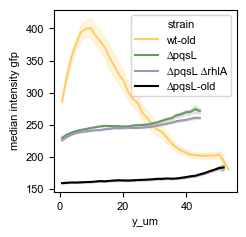

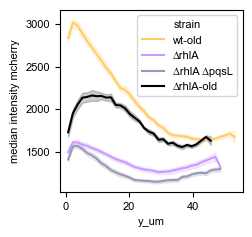

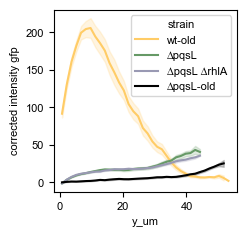

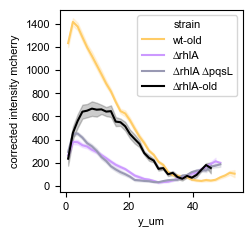

In [24]:
# --- Generate figure ---
final_width_in = 6 / 2.54
final_height_in = 6 / 2.54


fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))
# Output file
OUTPUT_FIGURE = 'S12_gradients_HQNO.pdf'
sns.lineplot(
    data=df_data_hqno,
    x='y_um',
    y='median intensity gfp',
    hue='strain',
    palette=COLORS_H,
    errorbar ='se',
    ax=ax
)

fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))
# Output file
OUTPUT_FIGURE = 'S12_gradients_RHL.pdf'
sns.lineplot(
    data=df_data_rhl,
    x='y_um',
    y='median intensity mcherry',
    hue='strain',
    palette=COLORS_R,
    errorbar ='se',
    ax=ax
)


fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))
# Output file
OUTPUT_FIGURE = 'S12_gradients_HQNO_corrected.pdf'
sns.lineplot(
    data=df_data_hqno,
    x='y_um',
    y='corrected intensity gfp',
    hue='strain',
    palette=COLORS_H,
    errorbar ='se',
    ax=ax
)

fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))
# Output file
OUTPUT_FIGURE = 'S12_gradients_RHL_corrected.pdf'
sns.lineplot(
    data=df_data_rhl,
    x='y_um',
    y='corrected intensity mcherry',
    hue='strain',
    palette=COLORS_R,
    errorbar ='se',
    ax=ax
)

In [ ]:


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def extract_stats(df, axis='y'):
    """Extract mean, std, and bin positions for specified axis"""
    df_axis = df[df['axis'] == axis].copy().sort_values('bin_left')
    mean_vals = df_axis['mean_regrowth_fraction'].values
    std_vals = df_axis['std_regrowth_fraction'].values
    bin_positions = df_axis['bin_left'].values
    return mean_vals, std_vals, bin_positions

def plot_with_shade(ax, mean, std, y, label, color, linestyle='-'):
    """Plot mean ± std as line with shaded error region"""
    line = ax.plot(y, mean, label=label, color=color, linewidth=1, linestyle=linestyle)
    ax.fill_between(y, mean - std, mean + std, color=color, alpha=0.3)
    return line[0]

# =============================================================================
# EXTRACT Y-AXIS STATISTICS
# =============================================================================

wt_mean, wt_std, wt_y = extract_stats(regrowth_wt, axis='y')
pqsL_mean, pqsL_std, pqsL_y = extract_stats(regrowth_pqsL, axis='y')
rhlA_mean, rhlA_std, rhlA_y = extract_stats(regrowth_rhlA, axis='y')
rhlApqsL_mean, rhlApqsL_std, rhlApqsL_y = extract_stats(regrowth_rhlApqsL, axis='y')

# =============================================================================
# REPLACE ZERO VALUES WITH LOD
# =============================================================================

# Replace zeros with LOD for visualization (prevents log-scale issues)
wt_mean = np.where(wt_mean == 0, LOD, wt_mean)
pqsL_mean = np.where(pqsL_mean == 0, LOD, pqsL_mean)
rhlA_mean = np.where(rhlA_mean == 0, LOD, rhlA_mean)
rhlApqsL_mean = np.where(rhlApqsL_mean == 0, LOD, rhlApqsL_mean)

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig = plt.figure(figsize=(3, 2))
ax = fig.add_axes([0.20, 0.25, 0.75, 0.70])

# Plot all strains (ΔrhlA with dotted line to distinguish)
line_wt = plot_with_shade(ax, wt_mean, wt_std, wt_y, 'WT', COLORS['WT'])
line_rhlA = plot_with_shade(ax, rhlA_mean, rhlA_std, rhlA_y, 'ΔrhlA', COLORS['ΔrhlA'], linestyle=':')
line_rhlApqsL = plot_with_shade(ax, rhlApqsL_mean, rhlApqsL_std, rhlApqsL_y, 'ΔpqsL ΔrhlA', COLORS['ΔrhlA ΔpqsL'])
line_pqsL = plot_with_shade(ax, pqsL_mean, pqsL_std, pqsL_y, 'ΔpqsL', COLORS['ΔpqsL'])

# Add LOD reference line
ax.axhline(y=LOD, color='lightgray', linestyle='--', linewidth=0.5, zorder=0)

# Axes labels and limits
ax.set_xlabel('Distance to PA (µm)', fontsize=8)
ax.set_ylabel('Regrowth probability', fontsize=8)
ax.set_xlim(0, 50)
ax.set_ylim(-0.002, 0.065)
ax.set_xticks([0, 10, 20, 30, 40, 50])

# Y-axis ticks with LOD label
y_ticks = [LOD, 0.02, 0.04, 0.06]
ax.set_yticks(y_ticks)
ax.set_yticklabels(['LOD', '0.02', '0.04', '0.06'], fontsize=8)

# Style (minimal spines, subtle grid)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Legend with italic formatting for gene names
ax.legend(
    [line_wt, line_pqsL, line_rhlA, line_rhlApqsL], 
    ['WT', r'$\it{ΔpqsL}$', r'$\it{ΔrhlA}$', r'$\it{ΔrhlA\ ΔpqsL}$'],
    frameon=False, fontsize=8, loc='upper right', 
    handlelength=1, handletextpad=0.2
)

# Save figure
plt.savefig(OUTPUT_FIGURE, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✅ Figure saved: {OUTPUT_FIGURE}")

plt.show()